<h1>Long Short-Term Memory (LSTM) Network From Scratch</h1>
<h4>Source: <a href="https://www.coursera.org/learn/nlp-sequence-models?" target="_blank">Deep Learning AI. Sequence Models</a></h4>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import image

<h2>Forward Propagation</h2>

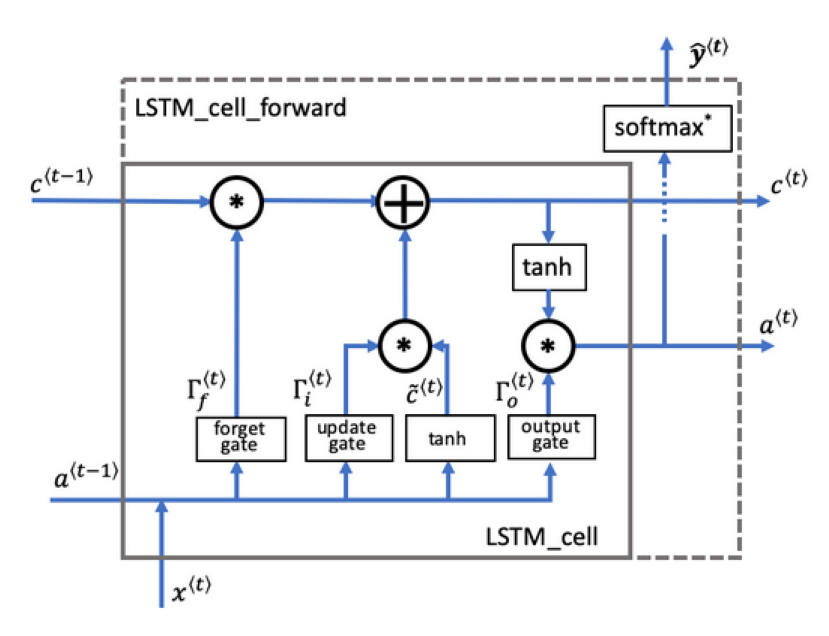

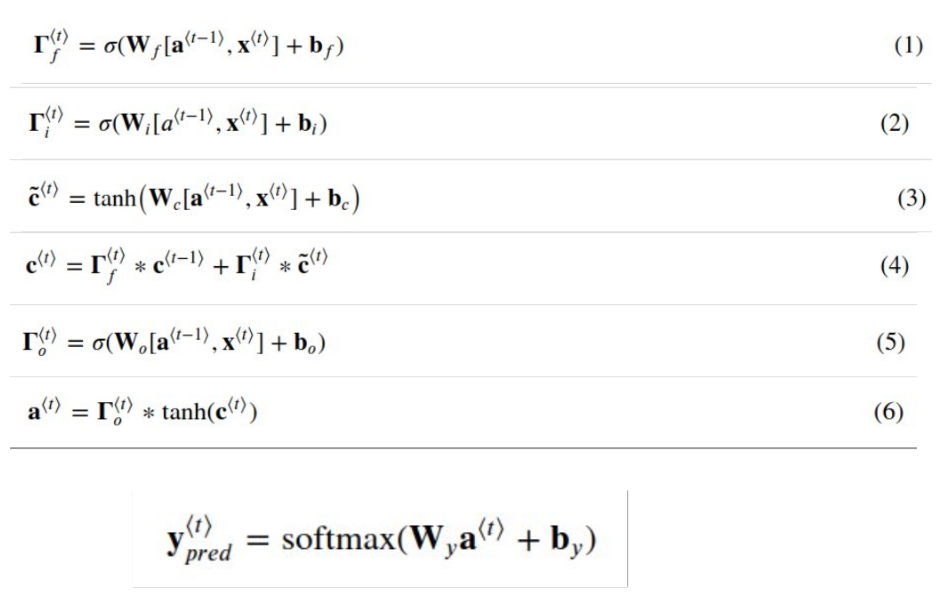

In [4]:
plt.figure(figsize=(12, 8))
im_path = "lstm.png"
img = image.imread(im_path)
plt.imshow(img)
plt.axis("off")
plt.show()

plt.figure(figsize=(12, 8))
im_path = "lstm1.png"
img = image.imread(im_path)
plt.imshow(img)
plt.axis("off")
plt.show()

In [6]:

def lstm_cell_forward(xt, a_prev, c_prev, parameters):
    """
    Implement a single forward step of the LSTM-cell as described in Figure above

    Arguments:
    xt -- your input data at timestep "t", numpy array of shape (n_x, m).
    a_prev -- Hidden state at timestep "t-1", numpy array of shape (n_a, m)
    c_prev -- Memory state at timestep "t-1", numpy array of shape (n_a, m)
    parameters -- python dictionary containing:
                        Wf -- Weight matrix of the forget gate, numpy array of shape (n_a, n_a + n_x)
                        bf -- Bias of the forget gate, numpy array of shape (n_a, 1)
                        Wi -- Weight matrix of the update gate, numpy array of shape (n_a, n_a + n_x)
                        bi -- Bias of the update gate, numpy array of shape (n_a, 1)
                        Wc -- Weight matrix of the first "tanh", numpy array of shape (n_a, n_a + n_x)
                        bc --  Bias of the first "tanh", numpy array of shape (n_a, 1)
                        Wo -- Weight matrix of the output gate, numpy array of shape (n_a, n_a + n_x)
                        bo --  Bias of the output gate, numpy array of shape (n_a, 1)
                        Wy -- Weight matrix relating the hidden-state to the output, numpy array of shape (n_y, n_a)
                        by -- Bias relating the hidden-state to the output, numpy array of shape (n_y, 1)
                        
    Returns:
    a_next -- next hidden state, of shape (n_a, m)
    c_next -- next memory state, of shape (n_a, m)
    yt_pred -- prediction at timestep "t", numpy array of shape (n_y, m)
    cache -- tuple of values needed for the backward pass, contains (a_next, c_next, a_prev, c_prev, xt, parameters)
    
    Note: ft/it/ot stand for the forget/update/output gates, cct stands for the candidate value (c tilde),
          c stands for the cell state (memory)
    """

    Wf = parameters["Wf"] 
    bf = parameters["bf"]
    Wi = parameters["Wi"] 
    bi = parameters["bi"] 
    Wc = parameters["Wc"] 
    bc = parameters["bc"]
    Wo = parameters["Wo"] 
    bo = parameters["bo"]
    Wy = parameters["Wy"] 
    by = parameters["by"]
    
    n_x, m = xt.shape
    n_y, n_a = Wy.shape

    concat = np.concatenate((a_prev, xt), axis=0)

    ft = sigmoid(np.dot(Wf, concat) + bf)
    it = sigmoid(np.dot(Wi, concat) + bi)
    cct = np.tanh(np.dot(Wc, concat) + bc)
    c_next = ft * c_prev + it * cct
    ot = sigmoid(np.dot(Wo, concat) + bo)
    a_next = ot * np.tanh(c_next)
    
    yt_pred = softmax(np.dot(Wy, a_next) + by)
   
    cache = (a_next, c_next, a_prev, c_prev, ft, it, cct, ot, xt, parameters)

    return a_next, c_next, yt_pred, cache

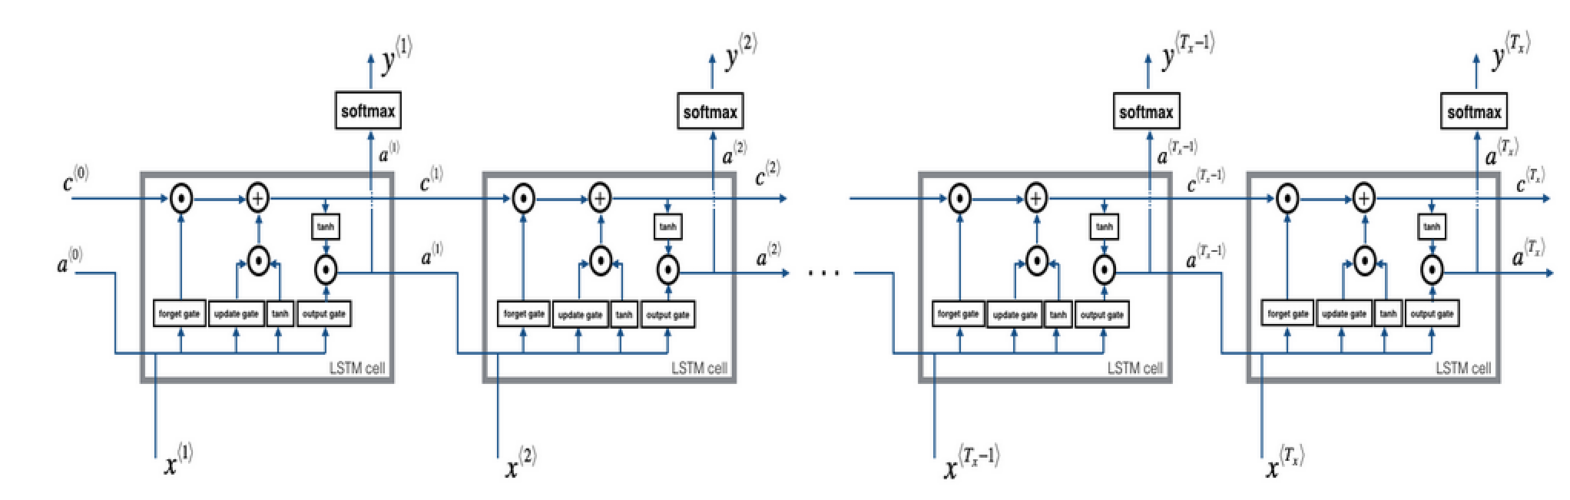

In [8]:
plt.figure(figsize=(20, 12))
im_path = "lstm2.png"
img = image.imread(im_path)
plt.imshow(img)
plt.axis("off")
plt.show()

In [10]:
def lstm_forward(x, a0, parameters):
    """
    Implement the forward propagation of the recurrent neural network using an LSTM-cell described in Figure above.

    Arguments:
    x -- Input data for every time-step, of shape (n_x, m, T_x).
    a0 -- Initial hidden state, of shape (n_a, m)
    parameters -- python dictionary containing:
                        Wf -- Weight matrix of the forget gate, numpy array of shape (n_a, n_a + n_x)
                        bf -- Bias of the forget gate, numpy array of shape (n_a, 1)
                        Wi -- Weight matrix of the update gate, numpy array of shape (n_a, n_a + n_x)
                        bi -- Bias of the update gate, numpy array of shape (n_a, 1)
                        Wc -- Weight matrix of the first "tanh", numpy array of shape (n_a, n_a + n_x)
                        bc -- Bias of the first "tanh", numpy array of shape (n_a, 1)
                        Wo -- Weight matrix of the output gate, numpy array of shape (n_a, n_a + n_x)
                        bo -- Bias of the output gate, numpy array of shape (n_a, 1)
                        Wy -- Weight matrix relating the hidden-state to the output, numpy array of shape (n_y, n_a)
                        by -- Bias relating the hidden-state to the output, numpy array of shape (n_y, 1)
                        
    Returns:
    a -- Hidden states for every time-step, numpy array of shape (n_a, m, T_x)
    y -- Predictions for every time-step, numpy array of shape (n_y, m, T_x)
    c -- The value of the cell state, numpy array of shape (n_a, m, T_x)
    caches -- tuple of values needed for the backward pass, contains (list of all the caches, x)
    """
    caches = []
    Wy = parameters['Wy'] 
    
    n_x, m, T_x = x.shape
    n_y, n_a = Wy.shape
    
    a = np.zeros((n_a, m, T_x), dtype=float)
    c = np.zeros((n_a, m, T_x), dtype=float)
    y = np.zeros((n_y, m, T_x), dtype=float)
    
    a_next = a0
    c_next = np.zeros((n_a, m), dtype=float)
    
    for t in range(T_x):
        
        xt = x[:,:,t]

        a_next, c_next, yt, cache = lstm_cell_forward(xt=xt, a_prev=a_next, c_prev=c_next, parameters=parameters)
        
        a[:,:,t] = a_next
        c[:,:,t]  = c_next
        y[:,:,t] = yt
        
        caches.append(cache)
        
    caches = (caches, x)

    return a, y, c, caches

<h2>Backward Propagation</h2>

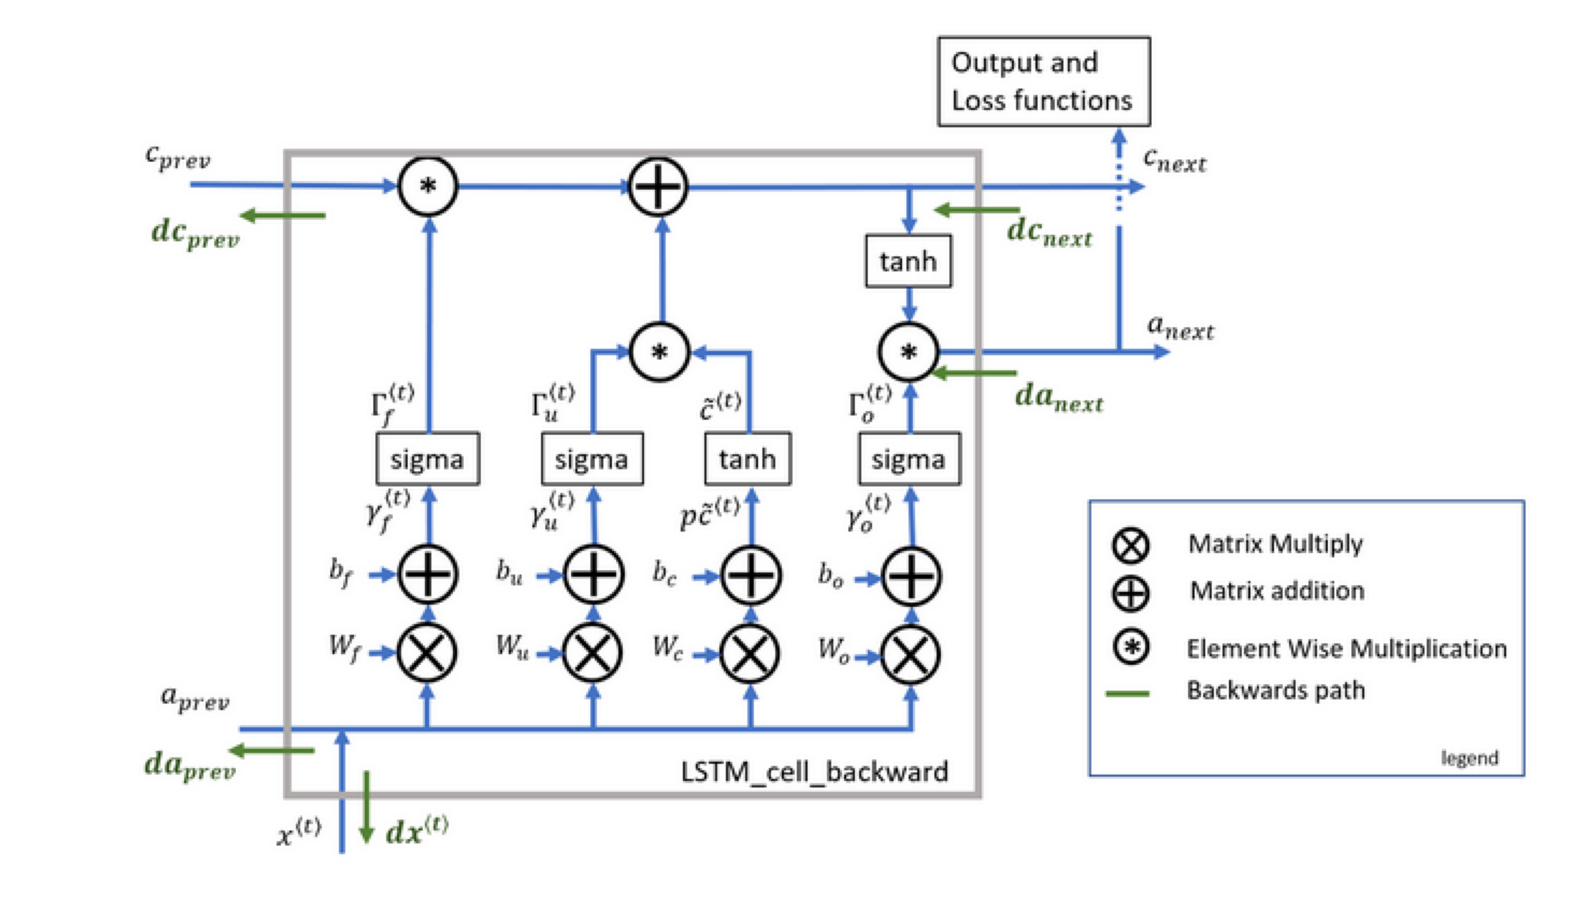

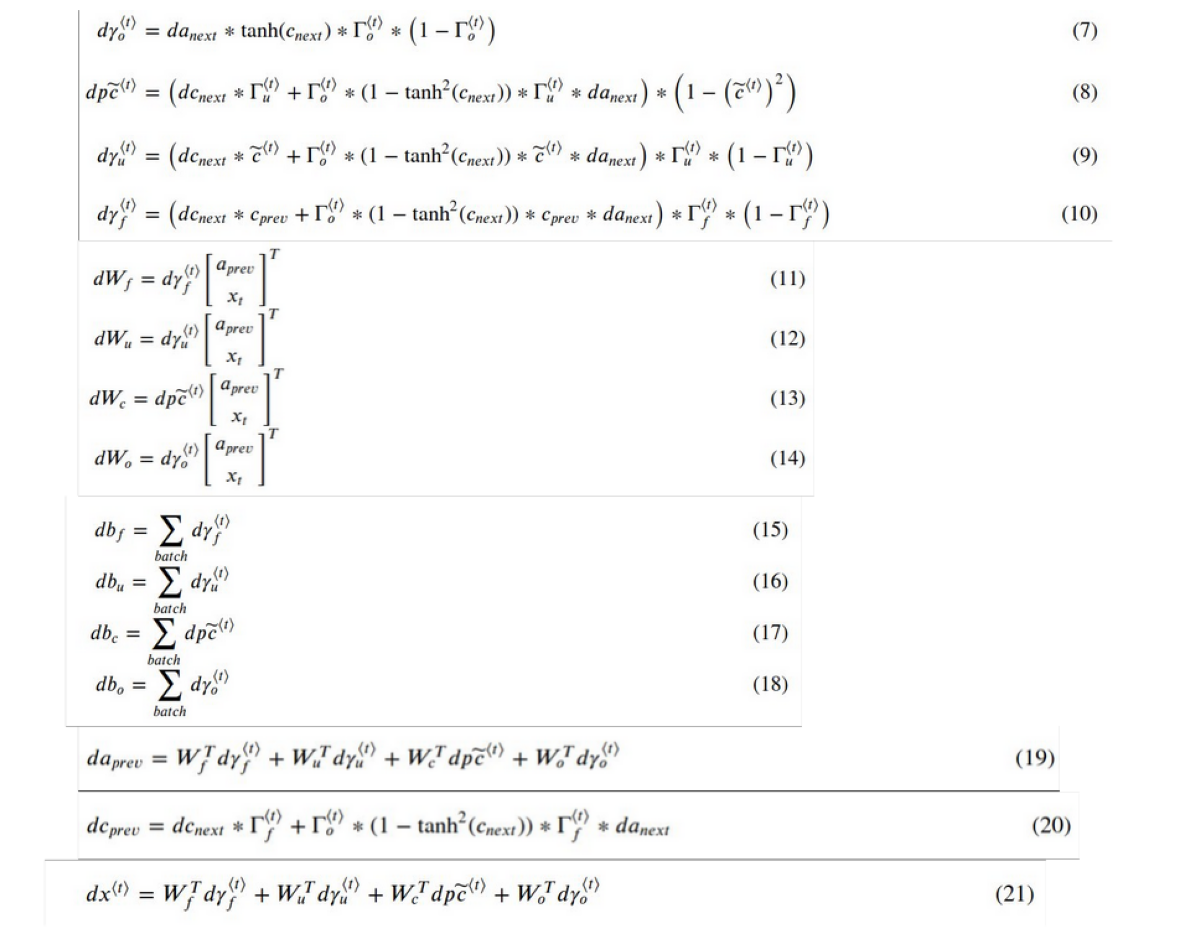

In [11]:
plt.figure(figsize=(20, 12))
im_path = "lstm3.png"
img = image.imread(im_path)
plt.imshow(img)
plt.axis("off")
plt.show()

plt.figure(figsize=(20, 12))
im_path = "lstm4.png"
img = image.imread(im_path)
plt.imshow(img)
plt.axis("off")
plt.show()

In [12]:
def lstm_cell_backward(da_next, dc_next, cache):
    """
    Implement the backward pass for the LSTM-cell (single time-step).

    Arguments:
    da_next -- Gradients of next hidden state, of shape (n_a, m)
    dc_next -- Gradients of next cell state, of shape (n_a, m)
    cache -- cache storing information from the forward pass

    Returns:
    gradients -- python dictionary containing:
                        dxt -- Gradient of input data at time-step t, of shape (n_x, m)
                        da_prev -- Gradient w.r.t. the previous hidden state, numpy array of shape (n_a, m)
                        dc_prev -- Gradient w.r.t. the previous memory state, of shape (n_a, m, T_x)
                        dWf -- Gradient w.r.t. the weight matrix of the forget gate, numpy array of shape (n_a, n_a + n_x)
                        dWi -- Gradient w.r.t. the weight matrix of the update gate, numpy array of shape (n_a, n_a + n_x)
                        dWc -- Gradient w.r.t. the weight matrix of the memory gate, numpy array of shape (n_a, n_a + n_x)
                        dWo -- Gradient w.r.t. the weight matrix of the output gate, numpy array of shape (n_a, n_a + n_x)
                        dbf -- Gradient w.r.t. biases of the forget gate, of shape (n_a, 1)
                        dbi -- Gradient w.r.t. biases of the update gate, of shape (n_a, 1)
                        dbc -- Gradient w.r.t. biases of the memory gate, of shape (n_a, 1)
                        dbo -- Gradient w.r.t. biases of the output gate, of shape (n_a, 1)
    """
    (a_next, c_next, a_prev, c_prev, ft, it, cct, ot, xt, parameters) = cache
    
    Wf = parameters["Wf"] 
    bf = parameters["bf"]
    Wi = parameters["Wi"] 
    bi = parameters["bi"] 
    Wc = parameters["Wc"] 
    bc = parameters["bc"]
    Wo = parameters["Wo"] 
    bo = parameters["bo"]
    Wy = parameters["Wy"] 
    by = parameters["by"]
    
    n_x, m = xt.shape
    n_a, m = a_next.shape
    
    dot = da_next * np.tanh(c_next) * ot * (1 - ot)
    dcct = (dc_next * it + ot * (1 - np.power(np.tanh(c_next), 2)) * it * da_next) * (1 - np.power(cct, 2))
    dit = (dc_next * cct + ot * (1 - np.power(np.tanh(c_next), 2)) * c_prev * da_next) * it * (1 - it)
    dft = (dc_next * c_prev * ot * (1 - np.power(np.tanh(c_next), 2)) * c_prev * da_next) * ft * (1 - ft)
    
    dWf = np.dot(dft, np.concatenate((a_prev, xt), axis=0).T)
    dWi = np.dot(dit, np.concatenate((a_prev, xt), axis=0).T)
    dWc = np.dot(dcct, np.concatenate((a_prev, xt), axis=0).T)
    dWo = np.dot(dot, np.concatenate((a_prev, xt), axis=0).T)
    
    dbf = np.sum(dft, axis=1, keepdims=True)
    dbi = np.sum(dit, axis=1, keepdims=True)
    dbc = np.sum(dcct, axis=1, keepdims=True)
    dbo = np.sum(dot, axis=1, keepdims=True)
    
    dconcat_a_x = np.dot(Wf.T, dft) + np.dot(Wi.T, dit) + np.dot(Wc.T, dcct) + np.dot(Wo.T, dot)
    da_prev = dconcat_a_x[:n_a, :]
    dc_prev = dc_next * ft + ot * (1 - np.power(np.tanh(c_next), 2)) * ft * da_next
    dxt = dconcat_a_x[n_a:, :]
    
    gradients = {"dxt": dxt, "da_prev": da_prev, "dc_prev": dc_prev, "dWf": dWf,"dbf": dbf, "dWi": dWi,"dbi": dbi,
                "dWc": dWc,"dbc": dbc, "dWo": dWo,"dbo": dbo}

    return gradients

In [13]:
def lstm_backward(da, caches):
    
    """
    Implement the backward pass for the RNN with LSTM-cell (over a whole sequence).

    Arguments:
    da -- Gradients w.r.t the hidden states, numpy-array of shape (n_a, m, T_x)
    caches -- cache storing information from the forward pass (lstm_forward)

    Returns:
    gradients -- python dictionary containing:
                        dx -- Gradient of inputs, of shape (n_x, m, T_x)
                        da0 -- Gradient w.r.t. the previous hidden state, numpy array of shape (n_a, m)
                        dWf -- Gradient w.r.t. the weight matrix of the forget gate, numpy array of shape (n_a, n_a + n_x)
                        dWi -- Gradient w.r.t. the weight matrix of the update gate, numpy array of shape (n_a, n_a + n_x)
                        dWc -- Gradient w.r.t. the weight matrix of the memory gate, numpy array of shape (n_a, n_a + n_x)
                        dWo -- Gradient w.r.t. the weight matrix of the output gate, numpy array of shape (n_a, n_a + n_x)
                        dbf -- Gradient w.r.t. biases of the forget gate, of shape (n_a, 1)
                        dbi -- Gradient w.r.t. biases of the update gate, of shape (n_a, 1)
                        dbc -- Gradient w.r.t. biases of the memory gate, of shape (n_a, 1)
                        dbo -- Gradient w.r.t. biases of the output gate, of shape (n_a, 1)
    """
    (caches, x) = caches
    (a1, c1, a0, c0, f1, i1, cc1, o1, x1, parameters) = caches[0]
    
    n_a, m, T_x = da.shape
    n_x, _ = x1.shape
    
    dx = np.zeros((n_x, m, T_x))
    da0 = np.zeros((n_a, m))
    da_prevt = np.zeros((n_a, m))
    dc_prevt = np.zeros((n_a, m))
    dWf = np.zeros((n_a, n_a + n_x))
    dWi = np.zeros((n_a, n_a + n_x))
    dWc = np.zeros((n_a, n_a + n_x))
    dWo = np.zeros((n_a, n_a + n_x))
    dbf = np.zeros((n_a, 1))
    dbi = np.zeros((n_a, 1))
    dbc = np.zeros((n_a, 1))
    dbo = np.zeros((n_a, 1))
    
    for t in reversed(range(T_x)):
       
        gradients = lstm_cell_backward(da[:,:,t] + da_prevt, dc_prevt, caches[t])
        
        da_prevt = gradients['da_prev']
        dc_prevt = gradients['dc_prev']
        dx[:,:,t] = gradients['dxt']
        dWf += gradients['dWf']
        dWi += gradients['dWi']
        dWc += gradients['dWc']
        dWo += gradients['dWo']
        dbf += gradients['dbf']
        dbi += gradients['dbi']
        dbc += gradients['dbc']
        dbo += gradients['dbo']
   
    da0 = da_prevt
    gradients = {"dx": dx, "da0": da0, "dWf": dWf,"dbf": dbf, "dWi": dWi,"dbi": dbi,
                "dWc": dWc,"dbc": dbc, "dWo": dWo,"dbo": dbo}
    
    return gradients